In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os

# ── local paths ──────────────────────────────────────────────
# os.getcwd() works in Jupyter notebooks (unlike __file__ which is undefined)
DATA_DIR = os.path.join(os.getcwd(), 'data')

infected_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'infected_timeseries.csv'))
rewiring_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'rewiring_timeseries.csv'))
degree_timeseries   = pd.read_csv(os.path.join(DATA_DIR, 'final_degree_histograms.csv'))

# convert dataframes into 2D arrays
obs_infected = infected_timeseries.pivot(
    index='replicate_id', columns='time',   values='infected_fraction').values
obs_rewire   = rewiring_timeseries.pivot(
    index='replicate_id', columns='time',   values='rewire_count').values
obs_degree   = degree_timeseries.pivot(
    index='replicate_id', columns='degree', values='count').values

print(f'Observed Infected Array Shape: {obs_infected.shape}')
print(f'Observed Rewire Array Shape:   {obs_rewire.shape}')
print(f'Observed Degree Array Shape:   {obs_degree.shape}')

In [ ]:
"""
Adaptive-network SIR epidemic simulator.

This module simulates an SIR (Susceptible-Infected-Recovered) epidemic
spreading on a network that evolves over time. The key idea is that
susceptible individuals can "rewire" their connections to avoid infected
neighbors, which couples the disease dynamics with the network topology.

The model proceeds in discrete time steps, each with three phases:
  1. Infection: infected nodes transmit the disease to susceptible neighbors
  2. Recovery: infected nodes recover (and become immune)
  3. Rewiring: susceptible nodes break links with infected neighbors and
     form new connections elsewhere

Reference: Gross et al. (2006), "Epidemic dynamics on an adaptive network",
Physical Review Letters, 96(20), 208701.
"""


def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None):
    """Run one replicate of the adaptive-network SIR model.

    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability. At each time step, each S-I edge
        transmits the infection independently with probability beta.
        Higher beta means the disease spreads faster.
    gamma : float in [0, 1]
        Recovery probability. At each time step, each infected node
        recovers independently with probability gamma.
        Higher gamma means shorter infectious period (on average 1/gamma steps).
    rho : float in [0, 1]
        Rewiring probability. At each time step, each S-I edge is
        rewired independently with probability rho. The susceptible
        node drops the link to its infected neighbor and connects to
        a randomly chosen new node instead.
        Higher rho means more active social distancing behavior.
    N : int, default=200
        Number of nodes (individuals) in the network.
    p_edge : float, default=0.05
        Probability of an edge between any two nodes in the initial
        Erdos-Renyi random graph. Expected initial degree is (N-1)*p_edge.
        With N=200 and p_edge=0.05, the expected degree is about 10.
    n_infected0 : int, default=5
        Number of nodes infected at time t=0. These are chosen
        uniformly at random (without replacement) from all N nodes.
    T : int, default=200
        Number of discrete time steps to simulate.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility. If None, a new
        generator is created with an arbitrary seed. Pass
        np.random.default_rng(seed) for reproducible runs.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
        Fraction of the population that is infected at each time step,
        from t=0 to t=T. Values are in [0, 1].
    rewire_counts : np.ndarray, shape (T+1,)
        Number of successful rewiring events at each time step.
        Always 0 at t=0 (no rewiring before the simulation starts).
    degree_histogram : np.ndarray, shape (31,)
        Histogram of node degrees at the final time step t=T.
        degree_histogram[d] = number of nodes with degree d, for d=0..29.
        degree_histogram[30] counts all nodes with degree >= 30.
    """
    if rng is None:
        rng = np.random.default_rng()

    # =====================================================================
    # STEP 0: Build the initial contact network as an Erdos-Renyi graph.
    #
    # We represent the network as an adjacency list using Python sets.
    # neighbors[i] is the set of node indices connected to node i.
    # Sets allow O(1) lookups for "is j a neighbor of i?" and efficient
    # add/remove operations, which is important for the rewiring step.
    #
    # For each pair (i, j) with i < j, we add an edge with probability
    # p_edge. This produces an undirected graph (if i is connected to j,
    # then j is also connected to i).
    # =====================================================================
    neighbors = [set() for _ in range(N)]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < p_edge:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # =====================================================================
    # Initialize the health state of each node.
    #
    # We encode states as integers:
    #   0 = Susceptible (S): can catch the disease
    #   1 = Infected (I):    currently infectious
    #   2 = Recovered (R):   immune, cannot be infected again
    #
    # At t=0, we pick n_infected0 nodes uniformly at random to be infected.
    # All other nodes start as susceptible.
    # =====================================================================
    state = np.zeros(N, dtype=np.int8)
    initial_infected = rng.choice(N, size=n_infected0, replace=False)
    state[initial_infected] = 1

    # Arrays to record the summary statistics at each time step
    infected_fraction = np.zeros(T + 1)
    rewire_counts = np.zeros(T + 1, dtype=np.int64)
    infected_fraction[0] = np.sum(state == 1) / N

    # =================================================================
    # Main simulation loop: iterate over T discrete time steps.
    # Each time step has three phases applied in order:
    #   Phase 1: Infection (S -> I transitions)
    #   Phase 2: Recovery  (I -> R transitions)
    #   Phase 3: Rewiring  (network topology changes)
    # =================================================================
    for t in range(1, T + 1):

        # =============================================================
        # PHASE 1: INFECTION (synchronous update)
        #
        # For every infected node i, look at each of its neighbors j.
        # If j is susceptible (state 0), the infection transmits with
        # probability beta.
        #
        # Important: we use synchronous (parallel) updating. We first
        # collect ALL new infections in a set, then apply them all at
        # once. This prevents "chain infections" within a single step
        # (where a newly infected node immediately infects its own
        # neighbors in the same step).
        # =============================================================
        new_infections = set()
        infected_nodes = np.where(state == 1)[0]

        for i in infected_nodes:
            for j in neighbors[i]:
                if state[j] == 0:  # j is susceptible
                    if rng.random() < beta:
                        new_infections.add(j)

        # Apply all new infections at once (synchronous update)
        for j in new_infections:
            state[j] = 1

        # =============================================================
        # PHASE 2: RECOVERY
        #
        # Each currently infected node (including those just infected
        # in Phase 1) recovers independently with probability gamma.
        # Recovery is permanent: recovered nodes move to state 2 (R)
        # and can never be infected again.
        #
        # We recompute the infected set to include newly infected nodes.
        # =============================================================
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            if rng.random() < gamma:
                state[i] = 2

        # =============================================================
        # PHASE 3: NETWORK REWIRING (adaptive behavior)
        #
        # This is what makes the model "adaptive": the network structure
        # changes in response to the disease.
        #
        # We look at all edges between a susceptible node (S) and an
        # infected node (I), called "S-I edges". For each such edge,
        # with probability rho, the susceptible node:
        #   1. Drops the connection to its infected neighbor
        #   2. Forms a new connection to a randomly chosen other node
        #      (that it is not already connected to)
        #
        # This models social distancing: susceptible individuals
        # actively avoid infected contacts.
        # =============================================================
        rewire_count = 0

        # First, collect all S-I edges. We iterate over susceptible
        # nodes and check their neighbors for infected ones.
        si_edges = []
        for i in range(N):
            if state[i] == 0:  # node i is susceptible
                for j in neighbors[i]:
                    if state[j] == 1:  # neighbor j is infected
                        si_edges.append((i, j))

        # Process each S-I edge for potential rewiring
        for s_node, i_node in si_edges:
            if rng.random() < rho:
                # Check that this edge still exists. An earlier rewiring
                # in this same loop may have already removed it (since
                # rewiring can affect shared neighborhoods).
                if i_node not in neighbors[s_node]:
                    continue

                # Remove the S-I edge (break the link in both directions)
                neighbors[s_node].discard(i_node)
                neighbors[i_node].discard(s_node)

                # Find all valid candidates for a new connection:
                # any node that is not s_node itself and not already
                # a neighbor of s_node. Note that the new partner can
                # be in any state (S, I, or R).
                candidates = []
                for k in range(N):
                    if k != s_node and k not in neighbors[s_node]:
                        candidates.append(k)

                # If there is at least one valid candidate, pick one
                # uniformly at random and create the new edge
                if candidates:
                    new_partner = rng.choice(candidates)
                    neighbors[s_node].add(new_partner)
                    neighbors[new_partner].add(s_node)
                    rewire_count += 1

        # Record summary statistics for this time step
        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t] = rewire_count

    # =====================================================================
    # Compute the degree histogram at the final time step.
    #
    # The degree of a node is its number of connections (neighbors).
    # We bin degrees from 0 to 29 individually, and lump all degrees >= 30
    # into a single bin (index 30). This gives a fixed-size output array
    # of shape (31,) regardless of the actual degree distribution.
    # =====================================================================
    degree_histogram = np.zeros(31, dtype=np.int64)
    for i in range(N):
        deg = min(len(neighbors[i]), 30)
        degree_histogram[deg] += 1

    return infected_fraction, rewire_counts, degree_histogram


In [ ]:
CACHE_PATH = os.path.join(os.getcwd(), 'data', 'sim_cache.npz')

def generate():
    N = 10000
    betas  = np.random.uniform(0.05, 0.5, N)
    gammas = np.random.uniform(0.02, 0.2, N)
    rhos   = np.random.uniform(0.0,  0.8, N)

    infected_fraction = np.zeros((N, 201))
    rewire_counts     = np.zeros((N, 201))
    degree_histogram  = np.zeros((N, 31))

    for i in range(N):
        infected_fraction[i], rewire_counts[i], degree_histogram[i] = simulate(
            betas[i], gammas[i], rhos[i]
        )

    return betas, gammas, rhos, infected_fraction, rewire_counts, degree_histogram


# ── load from cache if it exists, otherwise generate and save ──
if os.path.exists(CACHE_PATH):
    print("Loading simulation cache...")
    cache = np.load(CACHE_PATH)
    betas       = cache['betas']
    gammas      = cache['gammas']
    rhos        = cache['rhos']
    sim_infected = cache['sim_infected']
    sim_rewire   = cache['sim_rewire']
    sim_degree   = cache['sim_degree']
    print(f"Loaded {len(betas):,} simulations from cache.")
else:
    print("No cache found — running generate() now (this will take a while)...")
    betas, gammas, rhos, sim_infected, sim_rewire, sim_degree = generate()
    np.savez_compressed(
        CACHE_PATH,
        betas=betas,
        gammas=gammas,
        rhos=rhos,
        sim_infected=sim_infected,
        sim_rewire=sim_rewire,
        sim_degree=sim_degree
    )
    print(f"Saved {len(betas):,} simulations to {CACHE_PATH}")

In [ ]:
# define summary statistics (mean as default)
def summary_statistics(infected_fraction, rewire_counts, degree_histogram):
  mean_infected = np.mean(infected_fraction)
  mean_rewire = np.mean(rewire_counts)
  degrees = np.arange(degree_histogram.shape[1])
  mean_degree = np.sum(degree_histogram * degrees) / np.sum(degree_histogram)

  summary = np.array([mean_infected, mean_rewire, mean_degree])
  return summary

# compute summary statistics for observed & simulated data
obs_summary = summary_statistics(obs_infected, obs_rewire, obs_degree)
sim_summary = summary_statistics(sim_infected, sim_rewire, sim_degree)
print(len(obs_summary))
print(len(sim_summary))

3
3


In [ ]:
# compute distance between summary statistics of observed data and simulated data
def distance(obs_summary, sim_summary):
  dist = np.sqrt(np.sum(((obs_summary - sim_summary) / np.std(sim_summary)) ** 2))
  return dist

In [ ]:
# basic rejection ABC
def rejection_ABC():
    # Compute per-simulation summary statistics (one (3,) vector per simulation)
    # so we get an (N,) array of distances, not a single scalar.
    sim_s = np.zeros((len(betas), 3))
    for i in range(len(betas)):
        sim_s[i] = summary_statistics(
            sim_infected[i:i+1],
            sim_rewire[i:i+1],
            sim_degree[i:i+1]
        )

    # Normalise each dimension by the prior predictive std, then compute
    # Euclidean distance to the observed summary — shape (N,)
    std  = np.std(sim_s, axis=0) + 1e-8
    diff = (sim_s - obs_summary) / std
    dist = np.sqrt(np.sum(diff**2, axis=1))

    # Accept the closest 5% of simulations
    q = np.quantile(dist, 0.05)
    print(f'Acceptance threshold: {q:.4f}')
    accepted_betas  = betas[dist <= q]
    accepted_gammas = gammas[dist <= q]
    accepted_rhos   = rhos[dist <= q]
    print(f'{len(accepted_betas)} simulations accepted out of {len(betas)}')

    # plot accepted parameters against prior
    plt.hist(accepted_betas, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(betas, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Betas')
    plt.legend()
    plt.show()

    plt.hist(accepted_gammas, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(gammas, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Gammas')
    plt.legend()
    plt.show()

    plt.hist(accepted_rhos, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(rhos, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Rhos')
    plt.legend()
    plt.show()

0.11093507208562327


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


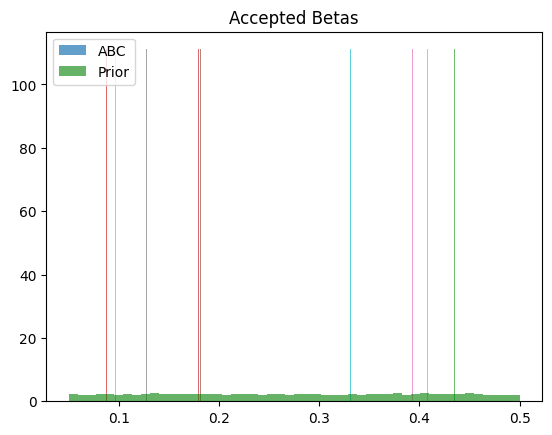

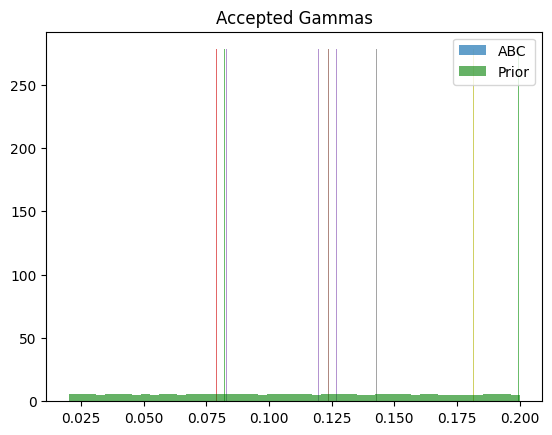

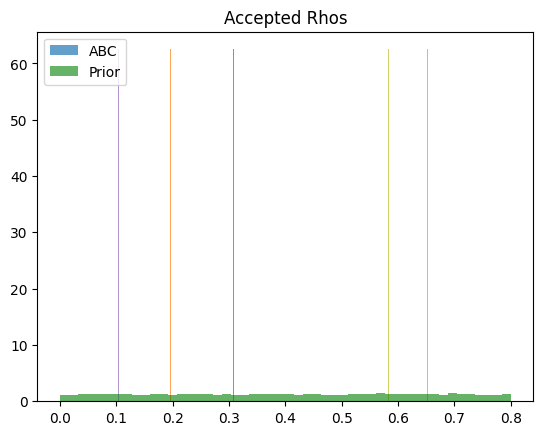

In [ ]:
rejection_ABC()

ABC_CACHE = os.path.join(os.getcwd(), 'data', 'abc_cache.npz')

if os.path.exists(ABC_CACHE):
    print("Loading ABC cache...")
    abc = np.load(ABC_CACHE)
    sim_base   = abc['sim_base']
    sim_inform = abc['sim_inform']
    obs_base   = abc['obs_base']
    obs_inform = abc['obs_inform']
    print("Loaded.")
# If no cache: sim_base / sim_inform / obs_base / obs_inform
# are computed below in Part 3 (and saved to cache at the end of that cell)

In [ ]:
# ============================================================
# PART 3: SUMMARY STATISTICS DESIGN
# Continues from simulator.ipynb after rejection_ABC() is run
#
# Already in memory:
#   betas, gammas, rhos          (10000,)
#   sim_infected                 (10000, 201)
#   sim_rewire                   (10000, 201)
#   sim_degree                   (10000, 31)
#   obs_infected                 (40, 201)
#   obs_rewire                   (40, 201)
#   obs_degree                   (40, 31)
#   obs_summary                  (3,)  from notebook
# ============================================================

QUANTILES = [0.01, 0.05, 0.10, 0.20]
Q_LABELS  = ['1%', '5%', '10%', '20%']
Q_COLORS  = ['#1a237e', '#1976D2', '#64B5F6', '#BBDEFB']   # dark→light blue


# ============================================================
# 1. SHARED FUNCTIONS
# ============================================================

def normalised_distance(sim_s, obs_s):
    """
    sim_s : (N_sim, D)
    obs_s : (D,)
    Normalise each dimension by prior predictive std so no
    single statistic dominates. Returns (N_sim,) distances.
    """
    std  = np.std(sim_s, axis=0) + 1e-8
    diff = (sim_s - obs_s) / std
    return np.sqrt(np.sum(diff**2, axis=1))


def run_ABC(dist, q):
    """Accept q-quantile closest simulations."""
    eps  = np.quantile(dist, q)
    mask = dist <= eps
    return betas[mask], gammas[mask], rhos[mask]


# ============================================================
# 2. BASELINE SUMMARIES — recompute row-by-row
#
# The notebook's summary_statistics() collapses all 10,000
# simulations into a single (3,) vector when called on the
# full array. We compute one (3,) vector per simulation so
# normalised_distance receives (10000, 3) not (3,).
# Statistics are identical to the notebook:
#   mean of infected_fraction, mean of rewire_counts, mean degree
# ============================================================

def baseline_stats_single(inf_i, rew_i, deg_i):
    mean_infected = np.mean(inf_i)
    mean_rewire   = np.mean(rew_i)
    degrees       = np.arange(deg_i.shape[1])
    mean_degree   = np.sum(deg_i * degrees) / np.sum(deg_i)
    return np.array([mean_infected, mean_rewire, mean_degree])


print("Computing baseline summaries row-by-row...")
sim_base = np.zeros((len(betas), 3))
for i in range(len(betas)):
    sim_base[i] = baseline_stats_single(
        sim_infected[i:i+1],
        sim_rewire[i:i+1],
        sim_degree[i:i+1]
    )
obs_base = obs_summary


# ============================================================
# 3. INFORMED SUMMARIES — redesigned 6 statistics
#
# DESIGN RATIONALE:
# The observed rewire_counts time series peaks at t ≈ 5
# (s5_old = 0.025 × 200 = 5 timesteps). Before t=5, the
# number of SI edges is still growing and rho has had limited
# time to restructure the network. After t=5, rho has begun
# cutting SI edges and both beta and rho are jointly shaping
# the curve. This gives us a data-driven definition of "early".
#
# From infected_fraction time series:
#   s1 — peak of the infected_fraction time series
#          → sensitive to both beta and rho
#          → captures epidemic severity
#
#   s2 — time at which infected_fraction peaks (normalised)
#          → captures epidemic speed
#          → high beta peaks early; high rho also peaks early
#            but through a different mechanism
#
#   s3 — early growth rate: mean of diff(infected_fraction)
#          over t=1 to t=4, BEFORE peak rewiring at t≈5
#          → in this window rho has had minimal time to act
#          → primarily driven by beta
#          → replaces final infected fraction which = 0 always
#
# From rewire_counts time series:
#   s4 — total area under rewire_counts, normalised by N=200
#          → primary rho signal: more rho = more total rewiring
#
#   s5 — rewire_count at the time of peak infected_fraction
#          → at peak infection, the number of SI edges is
#            determined by the balance of beta and rho together
#          → high rho cuts SI edges so rewiring is high even
#            at peak infection; high beta with low rho means
#            fewer SI edges survive to peak → less rewiring
#          → directly targets the beta-rho confound
#          → replaces time of peak rewiring which was weakly
#            correlated with all parameters
#
# From final_degree_histograms:
#   s6 — variance of the degree histogram
#          → rewiring redistributes edges unevenly, creating
#            high-degree hubs and isolated nodes
#          → high rho → high degree variance
#          → mean degree is preserved by rewiring (degree-
#            preserving by construction) so variance captures
#            the restructuring signal that mean cannot
# ============================================================

def informed_stats(infected, rewire, degree):
    """
    infected : (R, 201)
    rewire   : (R, 201)
    degree   : (R, 31)
    Returns (6,)
    """
    mean_inf = np.mean(infected, axis=0)   # (201,)
    mean_rew = np.mean(rewire,   axis=0)   # (201,)
    mean_deg = np.mean(degree,   axis=0)   # (31,)

    degrees = np.arange(mean_deg.shape[0])
    N_nodes = np.sum(mean_deg)

    # --- from infected_fraction ---

    # s1: peak of infected_fraction time series
    s1 = np.max(mean_inf)

    # s2: time at which infected_fraction peaks (normalised by T=200)
    t_peak = np.argmax(mean_inf)
    s2 = t_peak / 200.0

    # s3: early growth rate — mean timestep increase over t=1 to t=4
    # Window justified by: peak rewiring observed at t≈5 (from s5_old).
    # Before t=5, rho has had minimal time to restructure the network,
    # so growth is primarily driven by beta.
    s3 = np.mean(np.diff(mean_inf[0:5]))   # mean of 4 differences: t1-t0, t2-t1, t3-t2, t4-t3

    # --- from rewire_counts ---

    # s4: total area under rewire_counts, normalised by N=200
    s4 = np.sum(mean_rew) / 200.0

    # s5: rewire_count at the timestep of peak infected_fraction
    # At peak infection, SI edge count is shaped by the balance of
    # beta (creating new infections) and rho (cutting SI edges).
    # High rho → many SI edges already removed → rewiring is still
    # happening but at a different rate than high beta + low rho.
    s5 = mean_rew[t_peak]

    # --- from final_degree_histograms ---

    # s6: variance of degree histogram
    mean_d = np.sum(mean_deg * degrees) / N_nodes
    s6     = np.sum(mean_deg * (degrees - mean_d)**2) / N_nodes

    return np.array([s1, s2, s3, s4, s5, s6])


print("Computing informed summaries row-by-row...")
sim_inform = np.zeros((len(betas), 6))
for i in range(len(betas)):
    sim_inform[i] = informed_stats(
        sim_infected[i:i+1],
        sim_rewire[i:i+1],
        sim_degree[i:i+1]
    )

obs_inform = informed_stats(obs_infected, obs_rewire, obs_degree)
print("Observed informed summaries:", obs_inform.round(4))
print("s1 (peak inf):        ", obs_inform[0].round(4))
print("s2 (time to peak):    ", obs_inform[1].round(4),
      f" → t = {obs_inform[1]*200:.1f}")
print("s3 (early growth):    ", obs_inform[2].round(4))
print("s4 (total rewiring):  ", obs_inform[3].round(4))
print("s5 (rewire at peak):  ", obs_inform[4].round(4))
print("s6 (degree variance): ", obs_inform[5].round(4))


# ============================================================
# 4. RUN ABC FOR BOTH STAT SETS AT ALL TOLERANCE LEVELS
# ============================================================

dist_base   = normalised_distance(sim_base,   obs_base)
dist_inform = normalised_distance(sim_inform, obs_inform)

# results[label][ql] = (accepted_betas, accepted_gammas, accepted_rhos)
results = {}
for label, dist in [('Baseline', dist_base), ('Informed', dist_inform)]:
    results[label] = {}
    for q, ql in zip(QUANTILES, Q_LABELS):
        b, g, r = run_ABC(dist, q)
        results[label][ql] = (b, g, r)
        print(f"  {label} | {ql} → {len(b)} accepted")


# ============================================================
# PLOT 1 — CORRELATION HEATMAP
#
# Justifies the 6 statistic choices before any posteriors.
# The key things to look for:
#   s3 should correlate with beta but weakly with rho
#   s4, s5, s6 should correlate with rho
#   s1, s2 will be mixed — that is expected and honest
# ============================================================

stat_names_short = [
    's1: Peak inf. fraction',
    's2: Time to peak (inf.)',
    's3: Early growth rate',
    's4: Total rewire count',
    's5: Rewire at peak inf.',
    's6: Degree variance',
]
param_tex  = [r'$\beta$', r'$\gamma$', r'$\rho$']
param_arrs = [betas, gammas, rhos]

corr_mat = np.zeros((6, 3))
for j, p in enumerate(param_arrs):
    for k in range(6):
        corr_mat[k, j] = np.corrcoef(sim_inform[:, k], p)[0, 1]

fig, ax = plt.subplots(figsize=(4.5, 6.5))
im = ax.imshow(corr_mat, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(3))
ax.set_xticklabels(param_tex, fontsize=14)
ax.set_yticks(range(6))
ax.set_yticklabels(stat_names_short, fontsize=10.5)
ax.tick_params(axis='y', pad=4)
for i in range(6):
    for j in range(3):
        col = 'white' if abs(corr_mat[i, j]) > 0.45 else 'black'
        ax.text(j, i, f'{corr_mat[i,j]:.2f}',
                ha='center', va='center',
                fontsize=11, fontweight='bold', color=col)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title(
    'Correlation: Summary Statistics vs Parameters\n'
    '(prior predictive, N = 10,000)',
    fontsize=11, fontweight='bold', pad=10
)
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2 — MARGINAL POSTERIORS
#
# 2 rows (Baseline vs Informed) × 3 cols (β, γ, ρ)
# Each panel: prior (grey) + 4 tolerance levels dark→light.
# ============================================================

param_info = [
    (betas,  r'$\beta$  (infection rate)',  (0.05, 0.50), 0),
    (gammas, r'$\gamma$  (recovery rate)',  (0.02, 0.20), 1),
    (rhos,   r'$\rho$  (rewiring rate)',    (0.00, 0.80), 2),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7),
                         gridspec_kw={'hspace': 0.42, 'wspace': 0.30})
fig.suptitle(
    'ABC Marginal Posteriors — Baseline (3 means) vs Informed (6 stats)\n'
    r'Dark blue = $\varepsilon$ 1% (tight)  →  Light blue = $\varepsilon$ 20% (loose)',
    fontsize=12, fontweight='bold', y=1.02
)

for row, stat_label in enumerate(['Baseline', 'Informed']):
    for col, (prior_arr, plabel, xlim, tidx) in enumerate(param_info):
        ax = axes[row, col]
        ax.hist(prior_arr, bins=60, density=True,
                color='lightgrey', alpha=1.0, label='Prior', zorder=1)
        for qc, ql in zip(Q_COLORS, Q_LABELS):
            accepted_param = results[stat_label][ql][tidx]
            ax.hist(accepted_param, bins=40, density=True,
                    color=qc, alpha=0.75, label=f'ε = {ql}', zorder=2)
        ax.set_xlabel(plabel, fontsize=11)
        ax.set_ylabel('Density', fontsize=9)
        ax.set_xlim(xlim)
        ax.set_title(stat_label, fontsize=11, fontweight='bold')
        if row == 0 and col == 2:
            ax.legend(fontsize=8, title='Tolerance',
                      loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3 — JOINT β–ρ POSTERIOR  (identifiability plot)
#
# 3 rows (progressive data sources) × 4 cols (tolerance levels)
#   Row 1: infected_fraction only      (s1, s2, s3)
#   Row 2: + rewire_counts             (s1, s2, s3, s4, s5)
#   Row 3: + final_degree_histograms   (s1–s6)
#
# Annotation: Pearson r(β, ρ) in accepted samples
#   Strongly positive → β–ρ correlated → identifiability failure
#   Near zero         → parameters separated → successful inference
# ============================================================

data_sources = [
    ('infected_fraction only',       slice(0, 3), '#C62828'),
    ('+ rewire_counts',              slice(0, 5), '#E65100'),
    ('+ final_degree_histograms',    slice(0, 6), '#1565C0'),
]

fig, axes = plt.subplots(3, 4, figsize=(15, 10),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.32})
fig.suptitle(
    r'Joint Posterior: $\beta$ vs $\rho$  —  Identifiability by Data Source'
    '\n'
    r'Rows add one data source at a time  |  Columns show tolerance $\varepsilon$'
    '\n'
    r'Annotation: Pearson $r(\beta,\rho)$  →  near zero = parameters identified',
    fontsize=11, fontweight='bold', y=1.02
)

for row, (src_label, slc, color) in enumerate(data_sources):
    obs_s = obs_inform[slc]
    sim_s = sim_inform[:, slc]
    d     = normalised_distance(sim_s, obs_s)

    for col, (ql, q) in enumerate(zip(Q_LABELS, QUANTILES)):
        ax = axes[row, col]
        b, g, r = run_ABC(d, q)

        ax.scatter(b, r, alpha=0.35, s=5, color=color, rasterized=True)
        ax.set_xlim(0.05, 0.50)
        ax.set_ylim(0.00, 0.80)
        ax.set_xlabel(r'$\beta$', fontsize=10)

        if len(b) > 2:
            br_corr = np.corrcoef(b, r)[0, 1]
            ax.text(0.97, 0.97, f'r = {br_corr:.2f}',
                    transform=ax.transAxes,
                    ha='right', va='top', fontsize=9,
                    fontweight='bold',
                    color='darkred' if abs(br_corr) > 0.3 else 'darkgreen',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white', alpha=0.8,
                              edgecolor='none'))

        if row == 0:
            ax.set_title(f'ε = {ql}\n(n = {len(b)})',
                         fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'n = {len(b)}', fontsize=9)

        if col == 0:
            ax.set_ylabel(r'$\rho$', fontsize=10)
            ax.text(-0.38, 0.5, src_label,
                    transform=ax.transAxes,
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    rotation=90)
        else:
            ax.set_ylabel(r'$\rho$', fontsize=10)

plt.tight_layout()
plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

print("\n" + "="*72)
print(f"{'Setting':<30} {'β mean±std':>13} {'γ mean±std':>13} {'ρ mean±std':>13}")
print("="*72)
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        label = f"{stat_label} ε={ql}"
        print(f"{label:<30} "
              f"{np.mean(b):.3f}±{np.std(b):.3f}   "
              f"{np.mean(g):.3f}±{np.std(g):.3f}   "
              f"{np.mean(r):.3f}±{np.std(r):.3f}")
    print("-"*72)


# ============================================================
# IDENTIFIABILITY SUMMARY
# β–ρ correlation at 1% tolerance for each data source.
# This is the quantitative conclusion of Part 3.
# ============================================================

print("\n" + "="*60)
print("β–ρ posterior correlation at ε = 1%")
print("Near zero = identified.  Away from zero = failure.")
print("="*60)
for src_label, slc, _ in data_sources:
    obs_s = obs_inform[slc]
    sim_s = sim_inform[:, slc]
    d     = normalised_distance(sim_s, obs_s)
    b, g, r = run_ABC(d, 0.01)
    if len(b) > 2:
        br_corr = np.corrcoef(b, r)[0, 1]
        flag = "✓ identified" if abs(br_corr) < 0.3 else "✗ still confounded"
        print(f"  {src_label:<42} r = {br_corr:+.3f}  {flag}")
print("="*60)

# ============================================================
# Save ABC summaries to cache (so Cell 6 can load them next time)
# ============================================================
if not os.path.exists(ABC_CACHE):
    np.savez_compressed(
        ABC_CACHE,
        sim_base=sim_base,
        sim_inform=sim_inform,
        obs_base=obs_base,
        obs_inform=obs_inform
    )
    print(f"Saved ABC summaries to {ABC_CACHE}")